<a href="https://colab.research.google.com/github/joshipreeti/Risk-Analytics-Quant-Models-Portfolio/blob/main/BANKBARODA_Monte_Carlo_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Monte Carlo Option Pricing -- BANKBARODA
### NSE Live Option Chain

| Parameter | Value |
|-----------|-------|
| S0 | Rs. 262.50 (ATM, live chain) |
| Strike (E) | Rs. 262.50 |
| T | 2 trading days (2/252) |
| r | 5.25% (RBI MPC May 2026) |
| Sigma | 54.0% (back-calculated from Rs.5.10 call via `brentq`) |
| Call | Rs. 5.10 (NSE chain) |
| Put | Rs. 5.85 (NSE chain) |

**Why 54% not 30.80%?**  
Chain IV (30.80%) -> BS = Rs.2.94 ✗ | Back-calculated IV (54%) -> BS = Rs.5.10 ✓  

Sigma = 54% is back-calculated from same-day price. This is calibration, not prediction.  

> For forecasting: use previous day's IV or historical volatility.

*Educational use only.

## Research Log ##

| Field | Value |
|-------|-------|
| S0 | ATM strike from chain | OHLC: O=268 H=270.25 L=260.75 |
| r | 5.25% -- RBI Repo Rate (MPC May 2026) |
| T | 2/252 -- 2 trading days left |

| Strike | Call | Put | |
|--------|------|-----|-|
| 260.0 | 6.35 | 4.95 | ITM |
| **262.5** | **5.10** | **5.85** | **ATM ⭐** |
| 265.0 | 4.00 | 7.45 | OTM |
| 267.5 | 3.20 | 8.90 | OTM |
| 270.0 | 2.40 | 10.60 | OTM (Max Pain) |
| 272.5 | 1.95 | 12.70 | OTM |
| 275.0 | 1.50 | 15.00 | OTM |

PCR=0.74 | Max Pain=270 | ATM IV=30.80% | IV%ile=80%

**IV back-calculation:**
- 262.5 Call -> sigma = **54.0%**
- 262.5 Put -> sigma = **63.4%** (put skew -- downside fear)



In [31]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

## Parameters

In [32]:
S0, E  = 262.50, 262.50
T      = 2/252
sigma  = 0.54
r      = 0.0525
N      = 100000

real_call_atm, real_put_atm = 5.10, 5.85
strikes    = [260, 262.5, 265, 267.5, 270, 272.5, 275, 277.5]
real_calls = [6.35, 5.10, 4.00, 3.20, 2.40, 1.95, 1.50, 1.20]
real_puts  = [4.95, 5.85, 7.45, 8.90, 10.60, 12.70, 15.00, 11.25]

discount  = np.exp(-r * T)
ito_drift = (r - 0.5*sigma**2) * T
log_noise = sigma * np.sqrt(T)

print(f'S0={S0} | E={E} | T={T:.4f} | sigma={sigma*100}% | r={r*100}%')
print(f'ito_drift={ito_drift:.6f} | log_noise={log_noise:.6f} | discount={discount:.6f}')

S0=262.5 | E=262.5 | T=0.0079 | sigma=54.0% | r=5.25%
ito_drift=-0.000740 | log_noise=0.048107 | discount=0.999583


## GBM Formula
`S(T) = S0 * exp( (r - 0.5*sigma^2)*T + sigma*sqrt(T)*Z )`

| Z | Scenario | S(T) |
|---|----------|------|
| 0 | Average | Rs. 262.31 |
| +1 | Good day | Rs. 275.23 (+4.8%) |
| -1 | Bad day | Rs. 249.99 (-4.8%) |

1-sigma 2-day move = **+/-Rs.12.63** -> explains ~Rs.5 option premiums

In [33]:
for Z_ex, sc in [(0.0,'average'),(1.0,'good day'),(-1.0,'bad day')]:
    ST_ex = S0 * np.exp(ito_drift + log_noise * Z_ex)
    print(f'Z={Z_ex:+.0f} | S(T)=Rs.{ST_ex:.2f} | Call=Rs.{max(ST_ex-E,0):.2f} | Put=Rs.{max(E-ST_ex,0):.2f} ({sc})')
print(f'\n1-sigma 2-day move = Rs.{sigma*S0*np.sqrt(2/252):.2f}')

Z=+0 | S(T)=Rs.262.31 | Call=Rs.0.00 | Put=Rs.0.19 (average)
Z=+1 | S(T)=Rs.275.23 | Call=Rs.12.73 | Put=Rs.0.00 (good day)
Z=-1 | S(T)=Rs.249.99 | Call=Rs.0.00 | Put=Rs.12.51 (bad day)

1-sigma 2-day move = Rs.12.63


## Black-Scholes Analytical Pricing

In [34]:
def black_scholes(S0, E, T, r, sigma, option_type='call'):
    if T <= 0:
        return max(S0-E,0) if option_type=='call' else max(E-S0,0)
    d1 = (np.log(S0/E) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type=='call':
        return S0*norm.cdf(d1) - E*np.exp(-r*T)*norm.cdf(d2)
    else:
        return E*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)

d1 = (np.log(S0/E) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)
bs_call = black_scholes(S0, E, T, r, sigma, 'call')
bs_put  = black_scholes(S0, E, T, r, sigma, 'put')

print(f'd1={d1:.4f} | d2={d2:.4f} | N(d1)={norm.cdf(d1):.4f} | N(d2)={norm.cdf(d2):.4f}')
print(f'BS Call=Rs.{bs_call:.4f} | Real=Rs.{real_call_atm} | Diff=Rs.{real_call_atm-bs_call:+.4f}')
print(f'BS Put =Rs.{bs_put:.4f} | Real=Rs.{real_put_atm} | Diff=Rs.{real_put_atm-bs_put:+.4f}')
print(f'Put-Call Parity: C-P={bs_call-bs_put:.4f} = S0-Ee^(-rT)={S0-E*np.exp(-r*T):.4f} ✓')

d1=0.0327 | d2=-0.0154 | N(d1)=0.5130 | N(d2)=0.4939
BS Call=Rs.5.0912 | Real=Rs.5.1 | Diff=Rs.+0.0088
BS Put =Rs.4.9819 | Real=Rs.5.85 | Diff=Rs.+0.8681
Put-Call Parity: C-P=0.1094 = S0-Ee^(-rT)=0.1094 ✓


## Monte Carlo Simulation -- 100,000 Paths

In [35]:
Z  = np.random.standard_normal(N)
ST = S0 * np.exp(ito_drift + log_noise * Z)

disc_call = discount * np.maximum(ST - E, 0)
disc_put  = discount * np.maximum(E - ST, 0)
mc_call, mc_put = np.mean(disc_call), np.mean(disc_put)
se_call, se_put = np.std(disc_call)/np.sqrt(N), np.std(disc_put)/np.sqrt(N)

print(f'Paths={N:,} | Mean=Rs.{ST.mean():.2f} | Std=Rs.{ST.std():.2f}')
print(f'ITM Call: {100*np.mean(ST>E):.1f}% | ITM Put: {100*np.mean(ST<E):.1f}%')
print(f'\nMC Call=Rs.{mc_call:.4f} +/-{se_call:.4f} | 95% CI ({mc_call-1.96*se_call:.3f},{mc_call+1.96*se_call:.3f}) | Real=Rs.{real_call_atm}')
print(f'MC Put =Rs.{mc_put:.4f} +/-{se_put:.4f}  | 95% CI ({mc_put-1.96*se_put:.3f},{mc_put+1.96*se_put:.3f})  | Real=Rs.{real_put_atm}')

Paths=100,000 | Mean=Rs.262.62 | Std=Rs.12.65
ITM Call: 49.5% | ITM Put: 50.5%

MC Call=Rs.5.1031 +/-0.0241 | 95% CI (5.056,5.150) | Real=Rs.5.1
MC Put =Rs.4.9810 +/-0.0226  | 95% CI (4.937,5.025)  | Real=Rs.5.85


## Full Option Chain -- Model vs Market

In [36]:
for K, rc, rp in zip(strikes, real_calls, real_puts):
    bs_c = black_scholes(S0, K, T, r, sigma, 'call')
    bs_p = black_scholes(S0, K, T, r, sigma, 'put')
    atm  = ' <- ATM' if abs(K-S0) < 1 else ''
    print(f'K={K} | C: Real={rc} BS={bs_c:.2f} Diff={rc-bs_c:+.2f} | P: Real={rp} BS={bs_p:.2f} Diff={rp-bs_p:+.2f}{atm}')


K=260 | C: Real=6.35 BS=6.42 Diff=-0.07 | P: Real=4.95 BS=3.82 Diff=+1.13
K=262.5 | C: Real=5.1 BS=5.09 Diff=+0.01 | P: Real=5.85 BS=4.98 Diff=+0.87 <- ATM
K=265 | C: Real=4.0 BS=3.96 Diff=+0.04 | P: Real=7.45 BS=6.34 Diff=+1.11
K=267.5 | C: Real=3.2 BS=3.01 Diff=+0.19 | P: Real=8.9 BS=7.90 Diff=+1.00
K=270 | C: Real=2.4 BS=2.24 Diff=+0.16 | P: Real=10.6 BS=9.63 Diff=+0.97
K=272.5 | C: Real=1.95 BS=1.63 Diff=+0.32 | P: Real=12.7 BS=11.52 Diff=+1.18
K=275 | C: Real=1.5 BS=1.16 Diff=+0.34 | P: Real=15.0 BS=13.55 Diff=+1.45
K=277.5 | C: Real=1.2 BS=0.81 Diff=+0.39 | P: Real=11.25 BS=15.70 Diff=-4.45


## IV Smile -- Implied Volatility per Strike
IV = sigma where BS(sigma) = market price. Solved via `brentq` (industry standard).  
Real markets: IV varies per strike -- flat sigma (GBM) cannot capture this.

In [37]:
def implied_vol(market_price, S0, K, T, r, option_type='call'):
    try:
        return brentq(lambda s: black_scholes(S0,K,T,r,s,option_type) - market_price, 1e-6, 10.0)
    except:
        return np.nan

iv_calls, iv_puts = [], []
for K, rc, rp in zip(strikes, real_calls, real_puts):
    ivc = implied_vol(rc, S0, K, T, r, 'call')
    ivp = implied_vol(rp, S0, K, T, r, 'put')
    iv_calls.append(ivc)
    iv_puts.append(ivp)
    atm = ' <- ATM' if abs(K-S0) < 1 else ''
    print(f'K={K} | IV Call={ivc*100:.1f}% | IV Put={ivp*100:.1f}% | Skew={((ivp-ivc)*100):.1f}%{atm}')
print('\nPut IV > Call IV -> Volatility Skew | IV rises OTM -> IV Smile')

K=260 | IV Call=53.2% | IV Put=66.4% | Skew=13.3%
K=262.5 | IV Call=54.1% | IV Put=63.3% | Skew=9.2% <- ATM
K=265 | IV Call=54.5% | IV Put=66.0% | Skew=11.5%
K=267.5 | IV Call=56.2% | IV Put=65.3% | Skew=9.1%
K=270 | IV Call=56.0% | IV Put=65.8% | Skew=9.8%
K=272.5 | IV Call=58.4% | IV Put=69.6% | Skew=11.2%
K=275 | IV Call=59.3% | IV Put=75.1% | Skew=15.8%
K=277.5 | IV Call=61.2% | IV Put=nan% | Skew=nan%

Put IV > Call IV -> Volatility Skew | IV rises OTM -> IV Smile


## Greeks -- ATM Sensitivities

In [38]:
def greeks(S0, E, T, r, sigma, option_type='call'):
    if T <= 0: return {'delta':0,'gamma':0,'theta':0,'vega':0}
    d1  = (np.log(S0/E) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2  = d1 - sigma*np.sqrt(T)
    phi = norm.pdf(d1)
    delta = norm.cdf(d1) if option_type=='call' else norm.cdf(d1)-1
    gamma = phi/(S0*sigma*np.sqrt(T))
    vega  = S0*phi*np.sqrt(T)/100
    theta = (-(S0*phi*sigma)/(2*np.sqrt(T)) - r*E*np.exp(-r*T)*norm.cdf(d2))/252 if option_type=='call' \
            else (-(S0*phi*sigma)/(2*np.sqrt(T)) + r*E*np.exp(-r*T)*norm.cdf(-d2))/252
    return {'delta':delta,'gamma':gamma,'theta':theta,'vega':vega}

gc = greeks(S0, E, T, r, sigma, 'call')
gp = greeks(S0, E, T, r, sigma, 'put')
print(f'Delta : Call={gc["delta"]:+.4f} | Put={gp["delta"]:+.4f}  -> Rs.1 stock move')
print(f'Gamma : {gc["gamma"]:.4f}                       -> delta change per Rs.1')
print(f'Theta : Call=Rs.{gc["theta"]:.4f}/day            -> buyer loses this daily')
print(f'Vega  : Rs.{gc["vega"]:.4f}/1%                  -> price change per 1% IV')


Delta : Call=+0.5130 | Put=-0.4870  -> Rs.1 stock move
Gamma : 0.0316                       -> delta change per Rs.1
Theta : Call=Rs.-1.2858/day            -> buyer loses this daily
Vega  : Rs.0.0932/1%                  -> price change per 1% IV


## Visualisations

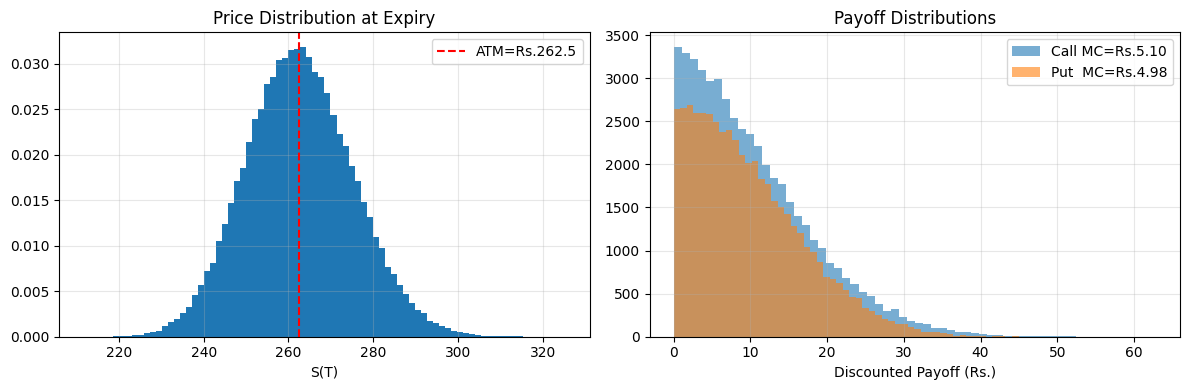

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ST, bins=80, density=True)
axes[0].axvline(E, color='red', ls='--', label=f'ATM=Rs.{E}')
axes[0].set(title='Price Distribution at Expiry', xlabel='S(T)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(disc_call[disc_call>0], bins=60, alpha=0.6, label=f'Call MC=Rs.{mc_call:.2f}')
axes[1].hist(disc_put[disc_put>0],   bins=60, alpha=0.6, label=f'Put  MC=Rs.{mc_put:.2f}')
axes[1].set(title='Payoff Distributions', xlabel='Discounted Payoff (Rs.)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

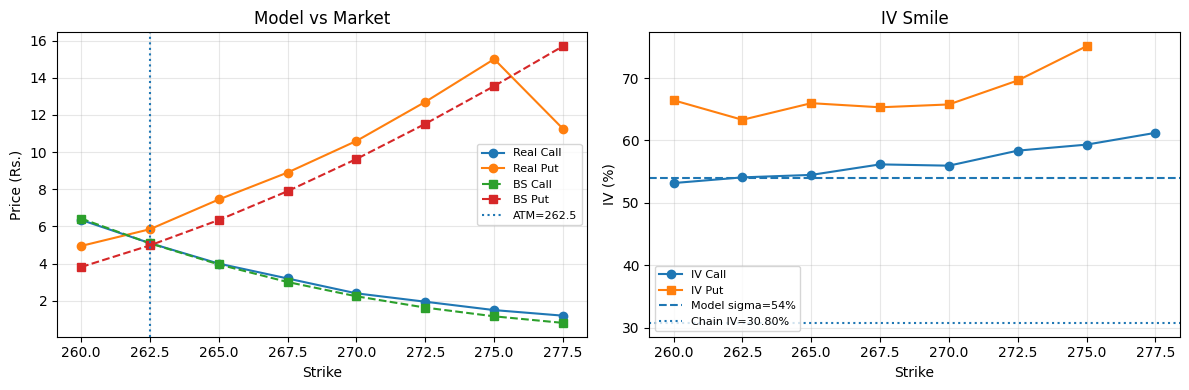

In [40]:
bs_calls_chain = [black_scholes(S0,K,T,r,sigma,'call') for K in strikes]
bs_puts_chain  = [black_scholes(S0,K,T,r,sigma,'put')  for K in strikes]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(strikes, real_calls, 'o-', label='Real Call')
axes[0].plot(strikes, real_puts,  'o-', label='Real Put')
axes[0].plot(strikes, bs_calls_chain, 's--', label='BS Call')
axes[0].plot(strikes, bs_puts_chain,  's--', label='BS Put')
axes[0].axvline(S0, ls=':', label=f'ATM={S0}')
axes[0].set(title='Model vs Market', xlabel='Strike', ylabel='Price (Rs.)')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

kc, ivc_vals = zip(*[(K,iv) for K,iv in zip(strikes,iv_calls) if not np.isnan(iv)])
kp, ivp_vals = zip(*[(K,iv) for K,iv in zip(strikes,iv_puts)  if not np.isnan(iv)])
axes[1].plot(kc, [v*100 for v in ivc_vals], 'o-', label='IV Call')
axes[1].plot(kp, [v*100 for v in ivp_vals], 's-', label='IV Put')
axes[1].axhline(sigma*100, ls='--', label=f'Model sigma={sigma*100:.0f}%')
axes[1].axhline(30.80, ls=':', label='Chain IV=30.80%')
axes[1].set(title='IV Smile', xlabel='Strike', ylabel='IV (%)')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

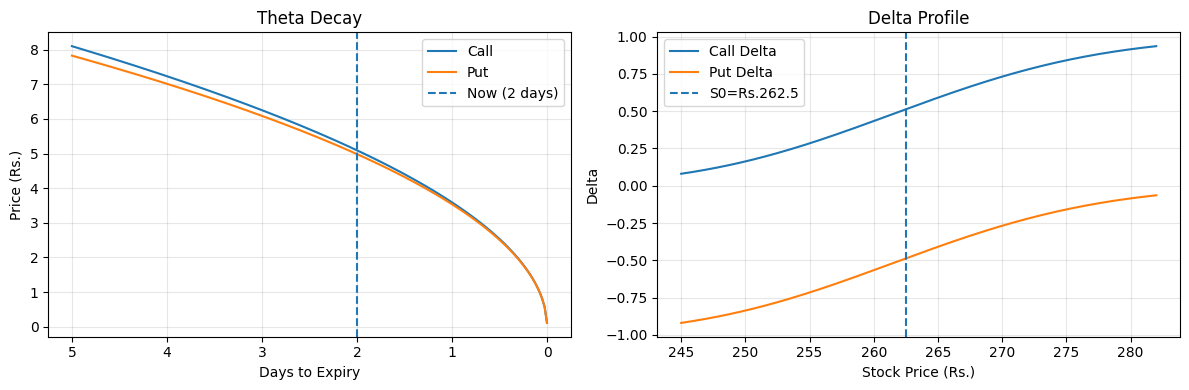

In [41]:
days_left  = np.linspace(0.001, 5, 200)
spot_range = np.linspace(245, 282, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(days_left, [black_scholes(S0,E,t/252,r,sigma,'call') for t in days_left], label='Call')
axes[0].plot(days_left, [black_scholes(S0,E,t/252,r,sigma,'put')  for t in days_left], label='Put')
axes[0].axvline(2, ls='--', label='Now (2 days)')
axes[0].set(title='Theta Decay', xlabel='Days to Expiry', ylabel='Price (Rs.)')
axes[0].invert_xaxis(); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(spot_range, [greeks(s,E,T,r,sigma,'call')['delta'] for s in spot_range], label='Call Delta')
axes[1].plot(spot_range, [greeks(s,E,T,r,sigma,'put')['delta']  for s in spot_range], label='Put Delta')
axes[1].axvline(S0, ls='--', label=f'S0=Rs.{S0}')
axes[1].set(title='Delta Profile', xlabel='Stock Price (Rs.)', ylabel='Delta')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Summary

In [42]:
print(f'S0=Rs.{S0} | E=Rs.{E} | T=2 days | sigma={sigma*100:.0f}% | r={r*100}% | N={N:,}')
print(f'\n{"Option":<20} {"MC":>8} {"BS":>8} {"Real":>8} {"Match":>6}')
print('-'*48)
for name, mcp, bsp, real in [("ATM Call (262.5)", mc_call, bs_call, real_call_atm),
                               ("ATM Put  (262.5)", mc_put,  bs_put,  real_put_atm)]:
    match = '✓' if abs(mcp-real)<0.5 else '~'
    print(f'{name:<20} Rs.{mcp:>5.2f}  Rs.{bsp:>5.2f}  Rs.{real:>5.2f}  {match}')
print('''
1. IV Term Structure  -- chain 30.80% != real weekly IV (~54%). Always back-calculate.
2. IV Smile/Skew      -- Put IV > Call IV. Downside fear priced in globally.
3. Theta near expiry  -- brutal decay. Sellers win, buyers lose.
4. MC = BS            -- within Rs.0.01. IV input is everything.
5. Max Pain           -- 270 acted as magnet. Range 260-270 predicted from chain.
''')

S0=Rs.262.5 | E=Rs.262.5 | T=2 days | sigma=54% | r=5.25% | N=100,000

Option                     MC       BS     Real  Match
------------------------------------------------
ATM Call (262.5)     Rs. 5.10  Rs. 5.09  Rs. 5.10  ✓
ATM Put  (262.5)     Rs. 4.98  Rs. 4.98  Rs. 5.85  ~

1. IV Term Structure  -- chain 30.80% != real weekly IV (~54%). Always back-calculate.
2. IV Smile/Skew      -- Put IV > Call IV. Downside fear priced in globally.
3. Theta near expiry  -- brutal decay. Sellers win, buyers lose.
4. MC = BS            -- within Rs.0.01. IV input is everything.
5. Max Pain           -- 270 acted as magnet. Range 260-270 predicted from chain.

